In [34]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
 

In [35]:
# =============================================================
# SECTION 1: AUTO-DETECT crop_part1 PATH
# Scans /kaggle/input and finds the crop_part1 folder.
# =============================================================
 
def find_crop_part1(base_path="/kaggle/input"):
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root) == "crop_part1":
            images = [f for f in files if f.lower().endswith((".jpg", ".png", ".jpeg"))]
            if images:
                return root
    return None
 
 
print("\n" + "="*60)
CROP_DIR = find_crop_part1()
 
if CROP_DIR is None:
    print("[ERROR] crop_part1 folder not found under /kaggle/input")
    print("        Make sure UTKFace dataset is attached.")
    raise SystemExit(1)
 
print(f"  Found  : {CROP_DIR}")
print("="*60 + "\n")


  Found  : /kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/crop_part1



In [36]:
# =============================================================
# SECTION 2: DATASET CLASS
# Reads filenames, extracts gender label (parts[1]).
# Returns (image_tensor, label) pairs.
# =============================================================
 
class UTKFaceDataset(Dataset):
 
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
 
        for fname in os.listdir(root_dir):
            if not fname.lower().endswith((".jpg", ".png", ".jpeg")):
                continue
            parts = fname.split("_")
            if len(parts) < 2:
                continue
            try:
                gender = int(parts[1])
                if gender not in [0, 1]:
                    continue
                self.samples.append((os.path.join(root_dir, fname), gender))
            except ValueError:
                continue
 
        print(f"  [crop_part1] {len(self.samples):,} valid images loaded.")
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        image = Image.open(filepath).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label
 

In [37]:
# =============================================================
# SECTION 3: TRANSFORMS
# Train  → augmentation + normalize
# Val/Test → normalize only (no augmentation — clean evaluation)
# =============================================================
 
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
 
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
 

In [38]:
# =============================================================
# SECTION 4: SPLIT INDICES  70 / 15 / 15
# We load the dataset ONCE with no transform to get all indices.
# Then we split indices into train/val/test.
# Then we create three Subset objects — each with its own transform.
# This is the correct way: same images, different transforms,
# clean separation, no data leakage.
# =============================================================
 
def make_splits(root_dir, seed=42):
    """
    Load dataset once, split indices 70/15/15,
    return three Subset objects with correct transforms.
    """
 
    # Load once — transform=None, we apply transforms via Subset wrappers
    base_dataset = UTKFaceDataset(root_dir, transform=None)
    total        = len(base_dataset)
 
    train_size = int(0.70 * total)
    val_size   = int(0.15 * total)
    test_size  = total - train_size - val_size
    # test_size gets the leftover so all images are used
 
    print(f"\n  Total  : {total:,}")
    print(f"  Train  : {train_size:,}  (70%)")
    print(f"  Val    : {val_size:,}  (15%)")
    print(f"  Test   : {test_size:,}  (15%)\n")
 
    # Split with fixed seed → reproducible every run
    generator = torch.Generator().manual_seed(seed)
    train_idx, val_idx, test_idx = random_split(
        range(total),
        [train_size, val_size, test_size],
        generator=generator
    )
 
    # Wrapper that applies a transform on top of a Subset
    class TransformSubset(Dataset):
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform
 
        def __len__(self):
            return len(self.subset)
 
        def __getitem__(self, idx):
            image, label = self.subset[idx]
            # image is still a PIL Image here (transform=None on base)
            if self.transform:
                image = self.transform(image)
            return image, label
 
    train_set = TransformSubset(Subset(base_dataset, train_idx.indices), TRAIN_TRANSFORM)
    val_set   = TransformSubset(Subset(base_dataset, val_idx.indices),   EVAL_TRANSFORM)
    test_set  = TransformSubset(Subset(base_dataset, test_idx.indices),  EVAL_TRANSFORM)
 
    return train_set, val_set, test_set
 

In [39]:
# =============================================================
# SECTION 5: MODEL
# EfficientNet-B0 pretrained, final layer → 2 classes
# =============================================================
 
def build_model(device):
    model = models.efficientnet_b0(pretrained=True)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(model.classifier[1].in_features, 2),
    )
    return model.to(device)
 

In [40]:
# =============================================================
# SECTION 6: TRAIN / VALIDATE / TEST FUNCTIONS
# =============================================================
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total * 100
 
 
def evaluate(model, loader, criterion, device):
    """Used for both validation and final test evaluation."""
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total * 100
 
 

In [41]:
# =============================================================
# SECTION 7: SAVE TRAINING CURVES
# =============================================================
 
def save_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses,   label="Val Loss")
    ax1.set_title("Loss per Epoch"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(train_accs, label="Train Acc")
    ax2.plot(val_accs,   label="Val Acc")
    ax2.set_title("Accuracy per Epoch"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"[Saved] {save_path}")
    plt.show()
 
 

[Device] GPU ✓
[Output] /kaggle/working/best_gender_model.pth

[Split] Creating 70 / 15 / 15 split...
  [crop_part1] 9,779 valid images loaded.

  Total  : 9,779
  Train  : 6,845  (70%)
  Val    : 1,466  (15%)
  Test   : 1,468  (15%)

  Training  |  20 epochs  |  batch 32  |  lr 0.0001
  Epoch [01/20]  Train → 0.4595 / 76.35%  |  Val → 0.3513 / 84.17%  ✓ saved
  Epoch [02/20]  Train → 0.2894 / 86.90%  |  Val → 0.3014 / 86.70%  ✓ saved
  Epoch [03/20]  Train → 0.2243 / 90.23%  |  Val → 0.3274 / 86.90%  ✓ saved
  Epoch [04/20]  Train → 0.1778 / 92.39%  |  Val → 0.3610 / 86.49%
  Epoch [05/20]  Train → 0.1342 / 94.49%  |  Val → 0.3608 / 87.93%  ✓ saved
  Epoch [06/20]  Train → 0.1059 / 95.84%  |  Val → 0.4154 / 87.65%
  Epoch [07/20]  Train → 0.0851 / 96.70%  |  Val → 0.4366 / 87.52%
  Epoch [08/20]  Train → 0.0705 / 97.33%  |  Val → 0.4890 / 87.04%
  Epoch [09/20]  Train → 0.0553 / 98.13%  |  Val → 0.5321 / 86.77%
  Epoch [10/20]  Train → 0.0478 / 98.23%  |  Val → 0.5541 / 87.65%
  Epoch

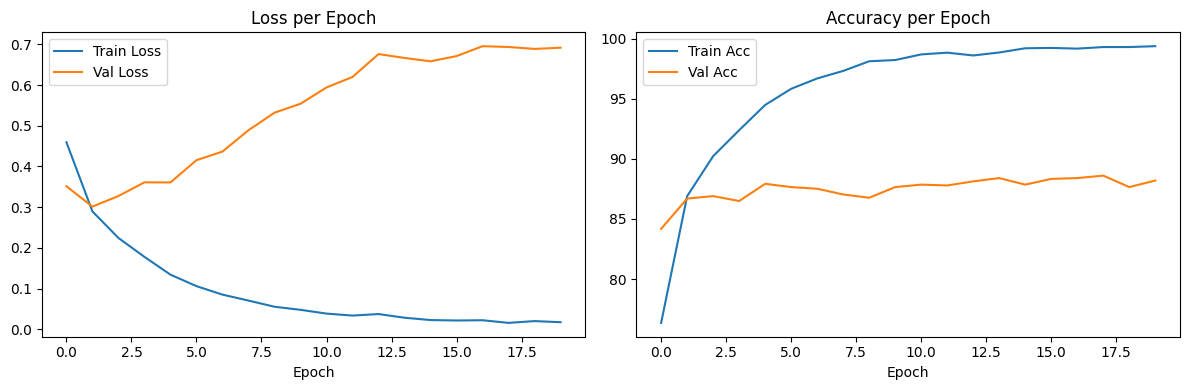

── Download from Kaggle Output panel ──────────────
  best_gender_model.pth   ← model weights
  training_curves.png     ← loss & accuracy plots


In [42]:
# =============================================================
# SECTION 8: MAIN
# =============================================================
 
if __name__ == "__main__":
 
    # ── Hyperparameters ───────────────────────────────────────
    EPOCHS       = 20
    BATCH_SIZE   = 32
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    OUTPUT_DIR   = "/kaggle/working"
    SAVE_PATH    = os.path.join(OUTPUT_DIR, "best_gender_model.pth")
    CURVES_PATH  = os.path.join(OUTPUT_DIR, "training_curves.png")
    # ─────────────────────────────────────────────────────────
 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {'GPU ✓' if device.type == 'cuda' else 'CPU — enable GPU in Kaggle settings!'}")
    print(f"[Output] {SAVE_PATH}\n")
 
    # ── Split dataset ─────────────────────────────────────────
    print("[Split] Creating 70 / 15 / 15 split...")
    train_set, val_set, test_set = make_splits(CROP_DIR, seed=42)
 
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
 
    # ── Build model, loss, optimizer, scheduler ───────────────
    model     = build_model(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS)
 
    # ── Training loop ─────────────────────────────────────────
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_acc = 0.0
 
    print("="*65)
    print(f"  Training  |  {EPOCHS} epochs  |  batch {BATCH_SIZE}  |  lr {LR}")
    print("="*65)
 
    for epoch in range(EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
 
        train_losses.append(tr_loss);  val_losses.append(vl_loss)
        train_accs.append(tr_acc);     val_accs.append(vl_acc)
 
        saved = ""
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), SAVE_PATH)
            saved = "  ✓ saved"
 
        print(f"  Epoch [{epoch+1:02d}/{EPOCHS}]  "
              f"Train → {tr_loss:.4f} / {tr_acc:.2f}%  |  "
              f"Val → {vl_loss:.4f} / {vl_acc:.2f}%{saved}")
 
    # ── Final test evaluation ─────────────────────────────────
    # Load the best saved weights and run on the held-out test set
    # Test set was never seen during training or model selection
    print(f"\n{'='*65}")
    print("  Loading best model for final TEST evaluation...")
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
 
    print(f"\n  ── FINAL RESULTS ──────────────────────────────")
    print(f"  Best Val Accuracy  : {best_val_acc:.2f}%")
    print(f"  Test Loss          : {test_loss:.4f}")
    print(f"  Test Accuracy      : {test_acc:.2f}%")
    print(f"  Model saved to     : {SAVE_PATH}")
    print(f"{'='*65}\n")
 
    save_curves(train_losses, val_losses, train_accs, val_accs, CURVES_PATH)
 
    print("── Download from Kaggle Output panel ──────────────")
    print("  best_gender_model.pth   ← model weights")
    print("  training_curves.png     ← loss & accuracy plots")